# STEP 1 : LOAD DATASET

In [741]:
# Import pandas library
import pandas as pd

# Load dataset
df = pd.read_csv("loan_dataset.csv")

# Display first 5 rows
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History Property_Area  
0             1.0         Urban  
1             1.0         Urban  
2             1.0         Urban  
3             NaN     

# STEP 2 : UNDERSTAND THE DATA

In [742]:
# Shape of dataset
print(df.shape)

# Column names
print(df.columns)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

(367, 12)
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-

# STEP 3 : VISUALIZE THE DATA

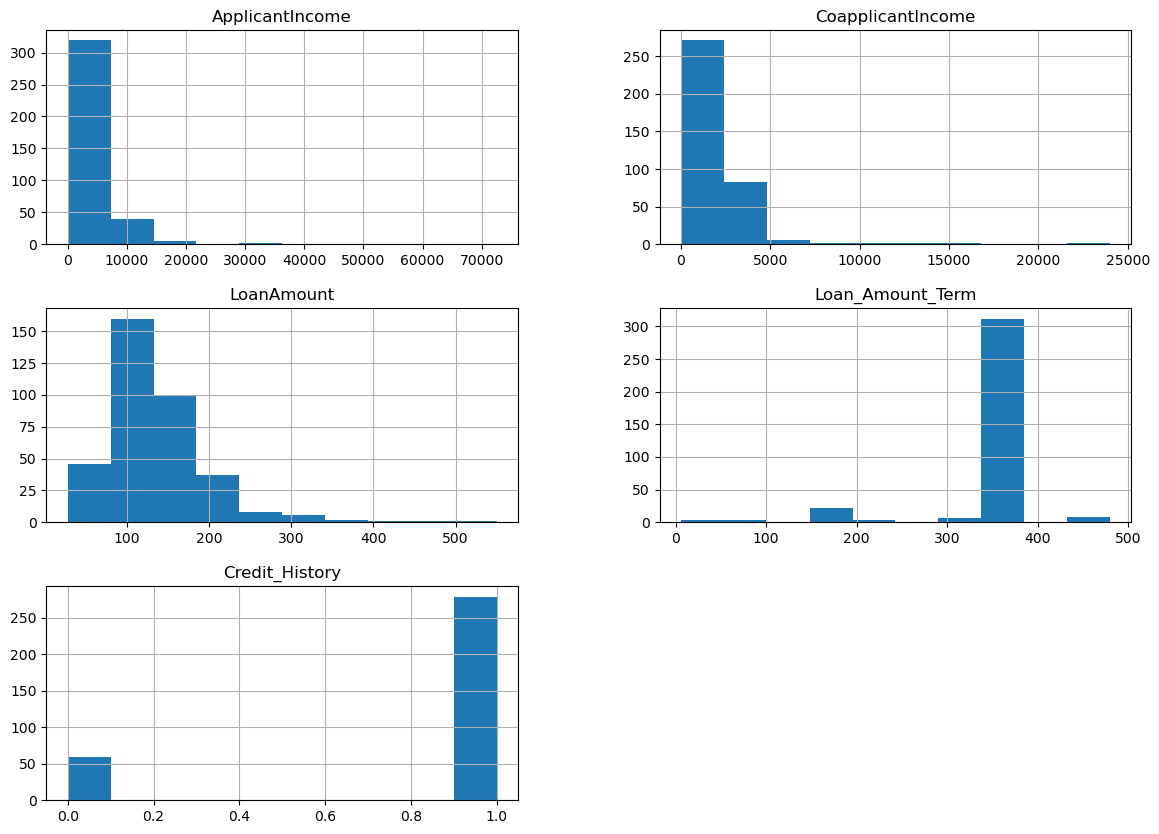

In [743]:
# Import matplotlib
import matplotlib.pyplot as plt

# Histogram
df.hist(figsize=(14,10))

plt.show()

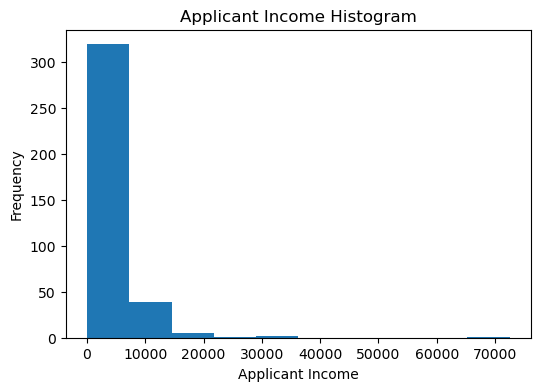

In [744]:
# Import matplotlib
import matplotlib.pyplot as plt

# Histogram for Applicant Income only

plt.figure(figsize=(6,4))

plt.hist(df["ApplicantIncome"])

plt.title("Applicant Income Histogram")

plt.xlabel("Applicant Income")

plt.ylabel("Frequency")

plt.show()

# STEP 4 : FIND NULL VALUES

In [745]:
# Check null values

print(df.isnull().sum())

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64


# STEP 5 : HANDLE NULL VALUES

# Handle Categorical Columns

In [746]:
# Fill categorical null values with mode

for col in df.columns:
    
    if df[col].dtype == "object":
        
        df[col] = df[col].fillna(df[col].mode()[0])

print("Categorical Null Values Handled")

Categorical Null Values Handled


# Handle Numerical Columns

In [747]:
# Fill numerical null values with median

for col in df.columns:
    
    if df[col].dtype != "object":
        
        df[col] = df[col].fillna(df[col].median())

print("Numerical Null Values Handled")

Numerical Null Values Handled


# Check Again

In [748]:
# Check null values again

print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


# STEP 6 : FIND OUTLIERS

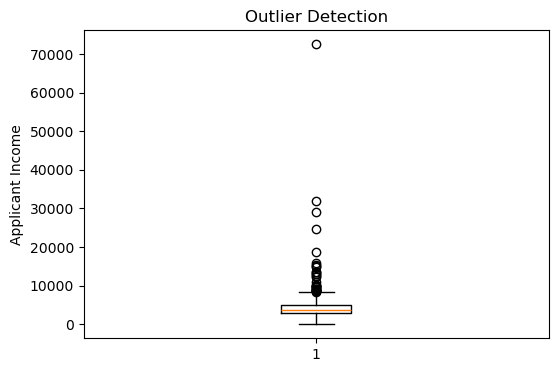

In [749]:
# Boxplot for ApplicantIncome

plt.figure(figsize=(6,4))

plt.boxplot(df["ApplicantIncome"])

plt.title("Outlier Detection")

plt.ylabel("Applicant Income")

plt.show()

# STEP 7 : HANDLE OUTLIERS

In [750]:
# Import numpy

import numpy as np

# Calculate Q1

Q1 = df["ApplicantIncome"].quantile(0.25)

# Calculate Q3

Q3 = df["ApplicantIncome"].quantile(0.75)

# Calculate IQR

IQR = Q3 - Q1

# Lower limit

lower_limit = Q1 - 1.5 * IQR

# Upper limit

upper_limit = Q3 + 1.5 * IQR

# Handle upper outliers

df["ApplicantIncome"] = np.where(
    
    df["ApplicantIncome"] > upper_limit,
    
    upper_limit,
    
    df["ApplicantIncome"]
)

# Handle lower outliers

df["ApplicantIncome"] = np.where(
    
    df["ApplicantIncome"] < lower_limit,
    
    lower_limit,
    
    df["ApplicantIncome"]
)

print("Outliers Handled Successfully")

Outliers Handled Successfully


# CHECK GRAPH AFTER HANDLING OUTLIERS

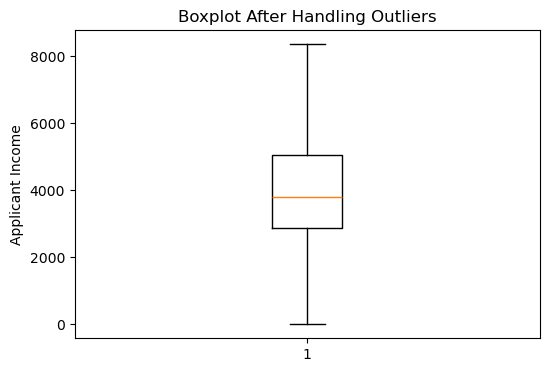

In [751]:
# Boxplot after handling outliers

plt.figure(figsize=(6,4))

plt.boxplot(df["ApplicantIncome"])

plt.title("Boxplot After Handling Outliers")

plt.ylabel("Applicant Income")

plt.show()

# STEP 8 : FEATURE ENGINEERING

In [752]:
# Create TotalIncome column

df["TotalIncome"] = (
    
    df["ApplicantIncome"] +
    
    df["CoapplicantIncome"]
)

# Display dataset

print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0           5720.0                  0       110.0             360.0   
1           3076.0               1500       126.0             360.0   
2           5000.0               1800       208.0             360.0   
3           2340.0               2546       100.0             360.0   
4           3276.0                  0        78.0             360.0   

   Credit_History Property_Area  TotalIncome  
0             1.0         Urban       5720.0  
1             1.0         Urban       4576.0  
2             1.0

# STEP 9 : DROP UNNECESSARY COLUMN

In [753]:
# Drop Loan_ID column

df.drop("Loan_ID", axis=1, inplace=True)

# Display dataset

print(df.head())

  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male     Yes          0      Graduate            No           5720.0   
1   Male     Yes          1      Graduate            No           3076.0   
2   Male     Yes          2      Graduate            No           5000.0   
3   Male     Yes          2      Graduate            No           2340.0   
4   Male      No          0  Not Graduate            No           3276.0   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0       110.0             360.0             1.0   
1               1500       126.0             360.0             1.0   
2               1800       208.0             360.0             1.0   
3               2546       100.0             360.0             1.0   
4                  0        78.0             360.0             1.0   

  Property_Area  TotalIncome  
0         Urban       5720.0  
1         Urban       4576.0  
2         Urban       6800.0 

# STEP 10 : CREATE TARGET COLUMN

In [ ]:
# Create Target Column

df["Loan_Status"] = np.where(
    (df["Credit_History"] == 1),
    (df["TotalIncome"] > 4000),
    1,
    0
)

# Input Features

X = df[[
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Credit_History",
    "TotalIncome"
]]

# Target

y = df["Loan_Status"]
y

0      1
1      1
2      1
3      1
4      1
      ..
362    1
363    1
364    1
365    1
366    1
Name: Loan_Status, Length: 367, dtype: int64

# STEP 11 : ENCODE CATEGORICAL DATA

In [755]:
# Import LabelEncoder

from sklearn.preprocessing import LabelEncoder

# Create object

le = LabelEncoder()

# Convert categorical columns into numerical

for col in df.columns:
    
    if df[col].dtype == "object":
        
        df[col] = le.fit_transform(df[col])

# Display dataset

print(df.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        1           0          0              0           5720.0   
1       1        1           1          0              0           3076.0   
2       1        1           2          0              0           5000.0   
3       1        1           2          0              0           2340.0   
4       1        0           0          1              0           3276.0   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0       110.0             360.0             1.0   
1               1500       126.0             360.0             1.0   
2               1800       208.0             360.0             1.0   
3               2546       100.0             360.0             1.0   
4                  0        78.0             360.0             1.0   

   Property_Area  TotalIncome  Loan_Status  
0              2       5720.0            1  
1              2       457

# STEP 12 : SEPARATE INPUT AND TARGET

In [756]:
# Input features

x = df.drop("Loan_Status", axis=1)

# Target column

y = df["Loan_Status"]

# Display input data

print(x.head())

# Display target data

print(y.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        1           0          0              0           5720.0   
1       1        1           1          0              0           3076.0   
2       1        1           2          0              0           5000.0   
3       1        1           2          0              0           2340.0   
4       1        0           0          1              0           3276.0   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0       110.0             360.0             1.0   
1               1500       126.0             360.0             1.0   
2               1800       208.0             360.0             1.0   
3               2546       100.0             360.0             1.0   
4                  0        78.0             360.0             1.0   

   Property_Area  TotalIncome  
0              2       5720.0  
1              2       4576.0  
2              2    

# STEP 13 : FEATURE SCALING

In [757]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

# Create scaler object

scaler = StandardScaler()

# Scale input data

x = scaler.fit_transform(x)

print("Feature Scaling Completed")

Feature Scaling Completed


# STEP 14 : TRAIN TEST SPLIT

In [758]:
# Import train_test_split

from sklearn.model_selection import train_test_split

# Divide dataset into training and testing

x_train, x_test, y_train, y_test = train_test_split(
    
    x,
    
    y,
    
    test_size = 0.2,
    
    random_state = 42
)

print("Training Data Size:", len(x_train))

print("Testing Data Size:", len(x_test))

Training Data Size: 293
Testing Data Size: 74


# STEP 15 : CREATE MODEL

In [759]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create model

model = LogisticRegression()

print(model)

LogisticRegression()


# STEP 16 : TRAIN MODE

In [760]:
# Train model

model.fit(x_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


# STEP 16 : TEST MODEL

In [761]:
# Predict test data

y_pred = model.predict(x_test)

print(y_pred)

[0 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0]


# STEP 17 : PREDICT NEW DATA

In [762]:
# Take one sample row

sample = x_test[0].reshape(1,-1)

# Predict sample

prediction = model.predict(sample)

# Display prediction

if prediction[0] == 1:
    
    print("Loan Approved")

else:
    
    print("Loan Not Approved")

Loan Not Approved


# STEP 18 : EVALUATION METRICS

# Accuracy Score

In [763]:
# Import accuracy_score

from sklearn.metrics import accuracy_score

# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


# Confusion Matrix

In [764]:
# Import confusion_matrix

from sklearn.metrics import confusion_matrix

# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[19  0]
 [ 0 55]]


# Classification Report

In [765]:
# Import classification_report

from sklearn.metrics import classification_report

# Classification report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        55

    accuracy                           1.00        74
   macro avg       1.00      1.00      1.00        74
weighted avg       1.00      1.00      1.00        74



# STEP 19 : SAVE MODEL

In [766]:
# Import pickle

import pickle

# Save trained model

pickle.dump(model, open("loan_model.pkl", "wb"))

# Save scaler

pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model and Scaler Saved Successfully")

Model and Scaler Saved Successfully
